# Phase 10 — Dual-Stream Network

**Objective:** Design and train the proposed dual-stream architecture — the primary architectural contribution of this project. Two parallel EfficientNetB0 branches process spatial (RGB) and frequency (DCT) inputs simultaneously. Their feature representations are concatenated and passed through a joint classification head. This forces the model to learn complementary discriminative signals from both domains simultaneously.

## Context: Why This Phase Exists

Phase 8 & 9 established the head-to-head benchmark between the Spatial CNN and Frequency CNN:

| Model | Accuracy | Precision | Recall | F1 | Specificity | AUC-ROC |
|---|---|---|---|---|---|---|
| Spatial CNN (Phase 2–3) | 0.6826 | 0.6434 | 0.8194 | 0.7208 | 0.5458 | 0.7626 |
| Frequency CNN (Phase 6–9) | *(fill after Phase 8–9 run)* | | | | | |
| **Dual-Stream (this phase)** | *(target: beat both)* | | | | | |

**Update the Frequency CNN row** with your actual Phase 8–9 results before running this notebook. 
The dual-stream goal is to exceed both single-stream models on every metric, 
especially Specificity and AUC-ROC which were the baseline's critical weaknesses.

## Phase 8 & 9 Results — Pre-Training Reference

Paste your actual Phase 8 & 9 metric values into `FREQ_METRICS` below before training starts. 
This cell prints a side-by-side table so the research narrative is complete inside one notebook. 
**You do not need to load any model file from Phase 8 & 9** — only the metric numbers.

In [1]:
# ============================================================
# These are the metric values from phase_08_09 evaluation
# ============================================================


SPATIAL_METRICS = {
    "Accuracy"    : 0.5065,
    "Precision"   : 0.5921,
    "Recall"      : 0.0418,
    "F1-Score"    : 0.0781,
    "Specificity" : 0.9712,
    "AUC-ROC"     : 0.4609,
}

FREQ_METRICS = {
    "Accuracy"    : 0.8326,  
    "Precision"   : 0.8507,   
    "Recall"      : 0.8068,   
    "F1-Score"    : 0.8282,   
    "Specificity" : 0.8584,   
    "AUC-ROC"     : 0.9140, 
}

# Print pre-training baseline comparison table
print("=" * 70)
print("PRE-TRAINING BASELINE COMPARISON (Phase 3 vs Phase 8 & 9)")
print("=" * 70)
print(f"{'Metric':<14} {'Spatial CNN':>14} {'Frequency CNN':>16} {'Winner':>10}")
print("-" * 70)
for metric in SPATIAL_METRICS:
    s = SPATIAL_METRICS[metric]
    f = FREQ_METRICS[metric]
    winner = "Frequency" if f > s else ("Spatial" if s > f else "Tie")
    print(f"{metric:<14} {s:>14.4f} {f:>16.4f} {winner:>10}")
print("=" * 70)
print()
print("These are the benchmarks the Dual-Stream model must beat.")
print("Target: higher Specificity and AUC-ROC than both single-stream models.")

PRE-TRAINING BASELINE COMPARISON (Phase 3 vs Phase 8 & 9)
Metric            Spatial CNN    Frequency CNN     Winner
----------------------------------------------------------------------
Accuracy               0.5065           0.8326  Frequency
Precision              0.5921           0.8507  Frequency
Recall                 0.0418           0.8068  Frequency
F1-Score               0.0781           0.8282  Frequency
Specificity            0.9712           0.8584    Spatial
AUC-ROC                0.4609           0.9140  Frequency

These are the benchmarks the Dual-Stream model must beat.
Target: higher Specificity and AUC-ROC than both single-stream models.


## Import Libraries

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import Sequence

2026-06-03 15:57:50.023650: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780502270.425883      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780502270.550396      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780502271.576424      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780502271.576478      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780502271.576481      23 computation_placer.cc:177] computation placer alr

## Configuration & Paths

In [3]:
BASE_PATH      = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images"
TRAIN_PATH     = os.path.join(BASE_PATH, "train")
TEST_PATH      = os.path.join(BASE_PATH, "test")
RESULT_DIR     = "/kaggle/working/results/dual_stream"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"

os.makedirs(RESULT_DIR,     exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

IMG_SIZE        = (128, 128)
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 10
EPOCHS_FINETUNE = 10
CLASS_MAP       = {"FAKE": 1, "REAL": 0}

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Define DCT Preprocessing Function

In [4]:
def dct_preprocess(image):
    image = image.astype(np.uint8)
    gray  = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray  = cv2.resize(gray, (128, 128))
    gray  = np.float32(gray)
    dct   = cv2.dct(gray)
    dct   = np.log(np.abs(dct) + 1)
    dct   = cv2.normalize(dct, None, 0, 1, cv2.NORM_MINMAX)
    dct   = np.stack([dct] * 3, axis=-1)
    return dct

## Define Dual-Stream Data Generator

Each batch returns a tuple of two inputs `(X_rgb, X_dct)` and one label array. The RGB input is normalized to [0, 1]. The DCT input goes through the full frequency preprocessing chain.

In [5]:
class DualStreamGenerator(Sequence):
    def __init__(self, directory, img_size=(128, 128), batch_size=32,
                 shuffle=True, class_map=None):
        self.img_size   = img_size
        self.batch_size = batch_size
        self.shuffle    = shuffle
        classes         = sorted(os.listdir(directory))
        self.class_map  = class_map or {cls: i for i, cls in enumerate(classes)}

        self.filepaths, self.labels = [], []
        for cls in classes:
            cdir = os.path.join(directory, cls)
            if not os.path.isdir(cdir):
                continue
            for f in os.listdir(cdir):
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.filepaths.append(os.path.join(cdir, f))
                    self.labels.append(self.class_map[cls])

        self.filepaths = np.array(self.filepaths)
        self.labels    = np.array(self.labels)
        self.indices   = np.arange(len(self.filepaths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_rgb = np.zeros((len(batch_idx), *self.img_size, 3), dtype=np.float32)
        X_dct = np.zeros((len(batch_idx), *self.img_size, 3), dtype=np.float32)
        y     = self.labels[batch_idx].astype(np.float32)

        for i, path in enumerate(self.filepaths[batch_idx]):
            img = cv2.imread(path)
            if img is None:
                continue
            img_rgb       = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_rgb_resized = cv2.resize(img_rgb, self.img_size).astype(np.float32) / 255.0
            X_rgb[i]      = img_rgb_resized
            X_dct[i]      = dct_preprocess(img_rgb)

        return (X_rgb, X_dct), y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

## Create Train / Validation / Test Generators

In [6]:
all_gen   = DualStreamGenerator(TRAIN_PATH, batch_size=BATCH_SIZE, shuffle=True, class_map=CLASS_MAP)
n_total   = len(all_gen.filepaths)
n_val     = int(n_total * 0.2)
shuffled  = np.random.permutation(n_total)
train_idx, val_idx = shuffled[n_val:], shuffled[:n_val]


class DualStreamSubset(DualStreamGenerator):
    def __init__(self, parent, indices, batch_size=32, shuffle=True):
        self.filepaths  = parent.filepaths[indices]
        self.labels     = parent.labels[indices]
        self.img_size   = parent.img_size
        self.class_map  = parent.class_map
        self.batch_size = batch_size
        self.shuffle    = shuffle
        self.indices    = np.arange(len(self.filepaths))
        if self.shuffle:
            np.random.shuffle(self.indices)


train_gen = DualStreamSubset(all_gen, train_idx, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = DualStreamSubset(all_gen, val_idx,   batch_size=BATCH_SIZE, shuffle=False)
test_gen  = DualStreamGenerator(TEST_PATH, batch_size=BATCH_SIZE, shuffle=False, class_map=CLASS_MAP)

(X_rgb_s, X_dct_s), y_s = train_gen[0]
print(f"RGB batch  : {X_rgb_s.shape}")
print(f"DCT batch  : {X_dct_s.shape}")
print(f"Label batch: {y_s[:6]}")

RGB batch  : (32, 128, 128, 3)
DCT batch  : (32, 128, 128, 3)
Label batch: [0. 1. 0. 0. 1. 1.]


## Build Dual-Stream Model

Two independent EfficientNetB0 backbones are instantiated — one per stream. Their pooled feature vectors are concatenated and passed through a shared classification head. Separate backbones ensure each stream develops domain-specific representations without interference.

In [7]:
def build_efficientnet_stream(stream_name, pretrained=True):
    with tf.name_scope(stream_name):
        inputs   = Input(shape=(128, 128, 3), name=f"{stream_name}_input")
        backbone = EfficientNetB0(
            weights="imagenet" if pretrained else None,
            include_top=False,
            input_tensor=inputs
        )
        outputs  = backbone.output
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=stream_name)


# RGB stream — ImageNet weights make sense (natural image features)
spatial_model   = build_efficientnet_stream("spatial",   pretrained=True)

# DCT stream — random init, ImageNet weights hurt here
frequency_model = build_efficientnet_stream("frequency", pretrained=False)

# === DEFINE OUTER INPUTS ===
rgb_input = Input(shape=(128, 128, 3), name="rgb_input")
dct_input = Input(shape=(128, 128, 3), name="dct_input")

# === PASS INPUTS THROUGH STREAMS ===
rgb_features = GlobalAveragePooling2D(name="gap_spatial"  )(spatial_model(rgb_input))
dct_features = GlobalAveragePooling2D(name="gap_frequency")(frequency_model(dct_input))

# === FUSION HEAD ===
merged = Concatenate(name="feature_fusion")([rgb_features, dct_features])
x      = Dense(256, activation="relu",    name="fusion_dense"  )(merged)
x      = Dropout(0.5,                     name="fusion_dropout")(x)
output = Dense(1,   activation="sigmoid", name="output"        )(x)

dual_model = Model(inputs=[rgb_input, dct_input], outputs=output)

# Freeze ONLY the spatial (RGB) backbone — frequency backbone must train from scratch
spatial_model.trainable   = False
frequency_model.trainable = True   # trains fully in frozen phase

dual_model.compile(
    optimizer=Adam(learning_rate=1e-4),  # lower lr — more stable with frozen spatial
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dual_model.summary()

I0000 00:00:1780502296.454136      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780502296.460452      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rgb_input           │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dct_input           │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial             │ (None, 4, 4,      │  4,049,571 │ rgb_input[0][0]   │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ frequency           │ (None, 4, 4,      │  4,049,571 │ dct_input[0][0]   │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap_spatial         │ (None, 1280)      │          0 │ spatial[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap_frequency       │ (None, 1280)      │          0 │ frequency[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 2560)      │          0 │ gap_spatial[0][0… │
│ (Concatenate)       │                   │            │ gap_frequency[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 256)       │    655,616 │ feature_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 256)       │          0 │ fusion_dense[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        257 │ fusion_dropout[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,755,015 (33.40 MB)

 Trainable params: 4,663,421 (17.79 MB)

 Non-trainable params: 4,091,594 (15.61 MB)

## Train — Frozen Backbones

In [8]:
checkpoint_cb = ModelCheckpoint(
    os.path.join(CHECKPOINT_DIR, "dual_stream_best.keras"),
    monitor="val_accuracy", save_best_only=True, mode="max", verbose=1
)

earlystop_frozen = EarlyStopping(
    monitor="val_accuracy", patience=4,
    restore_best_weights=True, verbose=1
)

history_frozen = dual_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=[checkpoint_cb, earlystop_frozen]
)

import os
os.makedirs("/kaggle/working/models", exist_ok=True)
dual_model.save("/kaggle/working/models/dual_stream_after_frozen.keras")
print("Frozen-stage model saved.")
print(f"Final frozen epoch — acc: {history_frozen.history['accuracy'][-1]:.4f}  val_acc: {history_frozen.history['val_accuracy'][-1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1780502347.924202      71 service.cc:152] XLA service 0x780a6c001d30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780502347.924245      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780502347.924250      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780502356.970469      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-03 15:59:30.126139: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 15:59:30.260427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-03 15:59:30.584732: E external/local_xl

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.6889 - loss: 0.5833
Epoch 1: val_accuracy improved from None to 0.81265, saving model to /kaggle/working/checkpoints/dual_stream_best.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/dual_stream_best.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 1334s 490ms/step - accuracy: 0.7486 - loss: 0.5176 - val_accuracy: 0.8127 - val_loss: 0.4189
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8215 - loss: 0.4135
Epoch 2: val_accuracy did not improve from 0.81265
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 401s 160ms/step - accuracy: 0.8263 - loss: 0.4051 - val_accuracy: 0.7912 - val_loss: 0.4506
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8493 - loss: 0.3579
Epoch 3: val_accuracy improved from 0.81265 to 0.83525, saving model to /kaggle/working/checkpoints/dual_stream_best.keras

Epoch 3: finished saving model to /kaggle/working/checkpoints/dual_stream_best.keras
2500/2500 ━━━━━━━━━━━━━━━━━━

## Fine-Tune — Unfreeze Top 20 Layers in Both Backbones

In [9]:
# Unfreeze top 20 layers in both stream models
for stream in [spatial_model, frequency_model]:
    stream.trainable = True
    for layer in stream.layers[:-20]:
        layer.trainable = False

dual_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

earlystop_cb = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_finetune = dual_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    callbacks=[checkpoint_cb, earlystop_cb]
)


Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9110 - loss: 0.2212
Epoch 1: val_accuracy improved from 0.84360 to 0.84820, saving model to /kaggle/working/checkpoints/dual_stream_best.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/dual_stream_best.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 626s 232ms/step - accuracy: 0.9139 - loss: 0.2144 - val_accuracy: 0.8482 - val_loss: 0.4228
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9189 - loss: 0.2005
Epoch 2: val_accuracy did not improve from 0.84820
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 618s 247ms/step - accuracy: 0.9203 - loss: 0.1984 - val_accuracy: 0.8457 - val_loss: 0.4283
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9224 - loss: 0.1947
Epoch 3: val_accuracy did not improve from 0.84820
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 574s 230ms/step - accuracy: 0.9234 - loss: 0.1924 - val_accuracy: 0.8469 - val_loss: 0.4353
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms

## Plot Training History

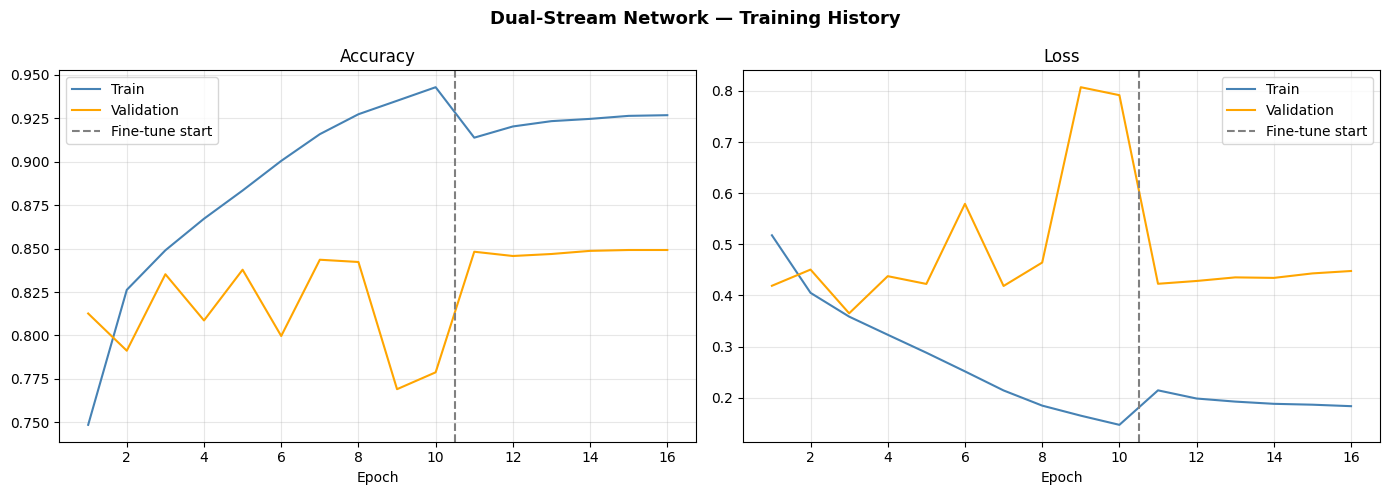

In [10]:
acc      = history_frozen.history["accuracy"]     + history_finetune.history["accuracy"]
val_acc  = history_frozen.history["val_accuracy"] + history_finetune.history["val_accuracy"]
loss     = history_frozen.history["loss"]         + history_finetune.history["loss"]
val_loss = history_frozen.history["val_loss"]     + history_finetune.history["val_loss"]
epochs_x = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Dual-Stream Network — Training History", fontsize=13, fontweight="bold")

for ax, t_vals, v_vals, title in [
    (axes[0], acc,  val_acc,  "Accuracy"),
    (axes[1], loss, val_loss, "Loss"),
]:
    ax.plot(epochs_x, t_vals, label="Train",      color="steelblue")
    ax.plot(epochs_x, v_vals, label="Validation", color="orange")
    ax.axvline(x=EPOCHS_FROZEN + 0.5, color="gray", linestyle="--", label="Fine-tune start")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "dual_stream_training_history.png"), dpi=150, bbox_inches="tight")
plt.show()

## Save Final Model

In [11]:
import os
os.makedirs("/kaggle/working/models", exist_ok=True)
dual_model.save("/kaggle/working/models/dual_stream_final.keras")
print("Model saved : /kaggle/working/models/dual_stream_final.keras")

Model saved : /kaggle/working/models/dual_stream_final.keras


Model loaded.
Test samples: 20000

Dual-Stream Evaluation Results:
------------------------------
  Accuracy      : 0.8455
  Precision     : 0.8488
  Recall        : 0.8407
  F1-Score      : 0.8448
  Specificity   : 0.8503
  AUC-ROC       : 0.9211

Text report saved  → /kaggle/working/results/dual_stream/dual_stream_eval_metrics.txt


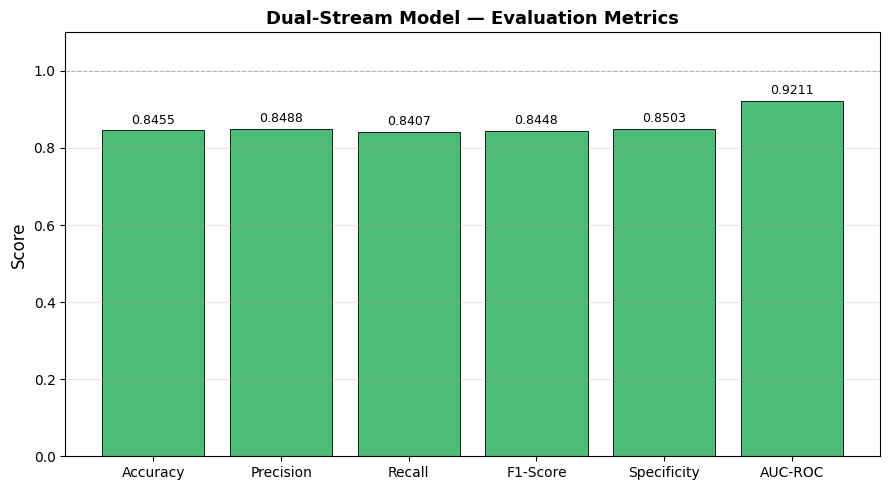

Metrics chart saved → /kaggle/working/results/dual_stream/dual_stream_metrics_bar.png


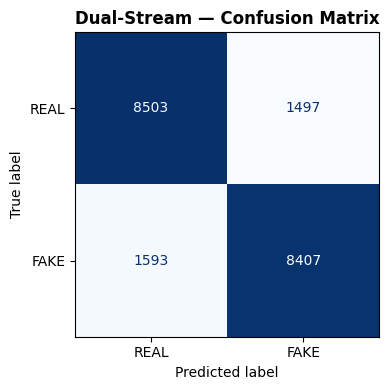

Confusion matrix saved → /kaggle/working/results/dual_stream/dual_stream_confusion_matrix.png


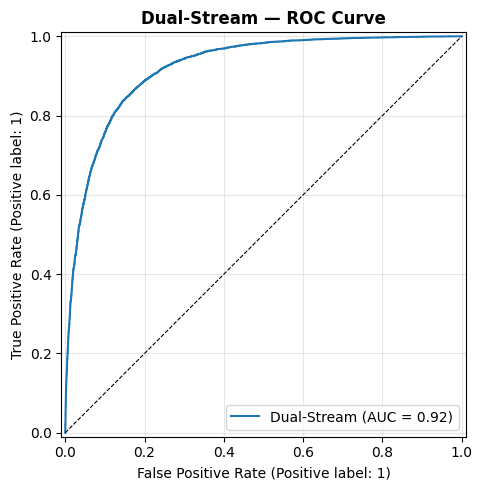

ROC curve saved     → /kaggle/working/results/dual_stream/dual_stream_roc_curve.png

All evaluation outputs saved to: /kaggle/working/results/dual_stream


In [12]:
# ============================================================
# EVALUATE + SAVE DUAL-STREAM RESULTS
# ============================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# ── Load model & run inference ───────────────────────────────
dual_model = tf.keras.models.load_model("/kaggle/working/models/dual_stream_final.keras")
print("Model loaded.")

test_gen = DualStreamGenerator(TEST_PATH, batch_size=BATCH_SIZE, shuffle=False, class_map=CLASS_MAP)
print(f"Test samples: {len(test_gen.filepaths)}")

y_true_all, y_prob_all = [], []
for i in range(len(test_gen)):
    (X_rgb_b, X_dct_b), y_b = test_gen[i]
    probs = dual_model.predict([X_rgb_b, X_dct_b], verbose=0).flatten()
    y_true_all.extend(y_b)
    y_prob_all.extend(probs)

y_true = np.array(y_true_all)
y_prob = np.array(y_prob_all)
y_pred = (y_prob >= 0.5).astype(int)

# ── Compute metrics ──────────────────────────────────────────
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp)
auc  = roc_auc_score(y_true, y_prob)

DUAL_METRICS = {
    "Accuracy"    : acc,
    "Precision"   : prec,
    "Recall"      : rec,
    "F1-Score"    : f1,
    "Specificity" : spec,
    "AUC-ROC"     : auc,
}

print("\nDual-Stream Evaluation Results:")
print("-" * 30)
for k, v in DUAL_METRICS.items():
    print(f"  {k:<14}: {v:.4f}")

# ── Save text report ─────────────────────────────────────────
os.makedirs(RESULT_DIR, exist_ok=True)
report_path = os.path.join(RESULT_DIR, "dual_stream_eval_metrics.txt")
with open(report_path, "w") as f:
    f.write("DUAL-STREAM MODEL — EVALUATION RESULTS\n")
    f.write("=" * 40 + "\n")
    for k, v in DUAL_METRICS.items():
        f.write(f"  {k:<14}: {v:.4f}\n")
    f.write("=" * 40 + "\n")
    f.write(f"\nConfusion Matrix:\n")
    f.write(f"  TP={tp}  FP={fp}\n")
    f.write(f"  FN={fn}  TN={tn}\n")
print(f"\nText report saved  → {report_path}")

# ── Metrics bar chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(DUAL_METRICS.keys(), DUAL_METRICS.values(),
              color="#4ebb78", edgecolor="black", linewidth=0.6)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Dual-Stream Model — Evaluation Metrics", fontsize=13, fontweight="bold")
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.grid(axis="y", alpha=0.3)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
            f"{h:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
metrics_chart_path = os.path.join(RESULT_DIR, "dual_stream_metrics_bar.png")
plt.savefig(metrics_chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Metrics chart saved → {metrics_chart_path}")

# ── Confusion matrix ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["REAL", "FAKE"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Dual-Stream — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
cm_path = os.path.join(RESULT_DIR, "dual_stream_confusion_matrix.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Confusion matrix saved → {cm_path}")

# ── ROC curve ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax, name="Dual-Stream")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_title("Dual-Stream — ROC Curve", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(RESULT_DIR, "dual_stream_roc_curve.png")
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"ROC curve saved     → {roc_path}")

print("\nAll evaluation outputs saved to:", RESULT_DIR)

## Final Three-Way Comparison

After training completes, paste the dual-stream evaluation metrics from Phase 8 & 9 style 
evaluation (run on `dual_stream_final.keras`) into `DUAL_METRICS` below and re-run this cell. 
This produces the core research comparison table for your report.

FINAL THREE-WAY COMPARISON
Metric            Spatial CNN    Frequency CNN    Dual-Stream       Best
------------------------------------------------------------------------------
Accuracy               0.5065           0.8326         0.8541       Dual
Precision              0.5921           0.8507         0.8483       Freq
Recall                 0.0418           0.8068         0.8625       Dual
F1-Score               0.0781           0.8282         0.8554       Dual
Specificity            0.9712           0.8584         0.8458    Spatial
AUC-ROC                0.4609           0.9140         0.9305       Dual


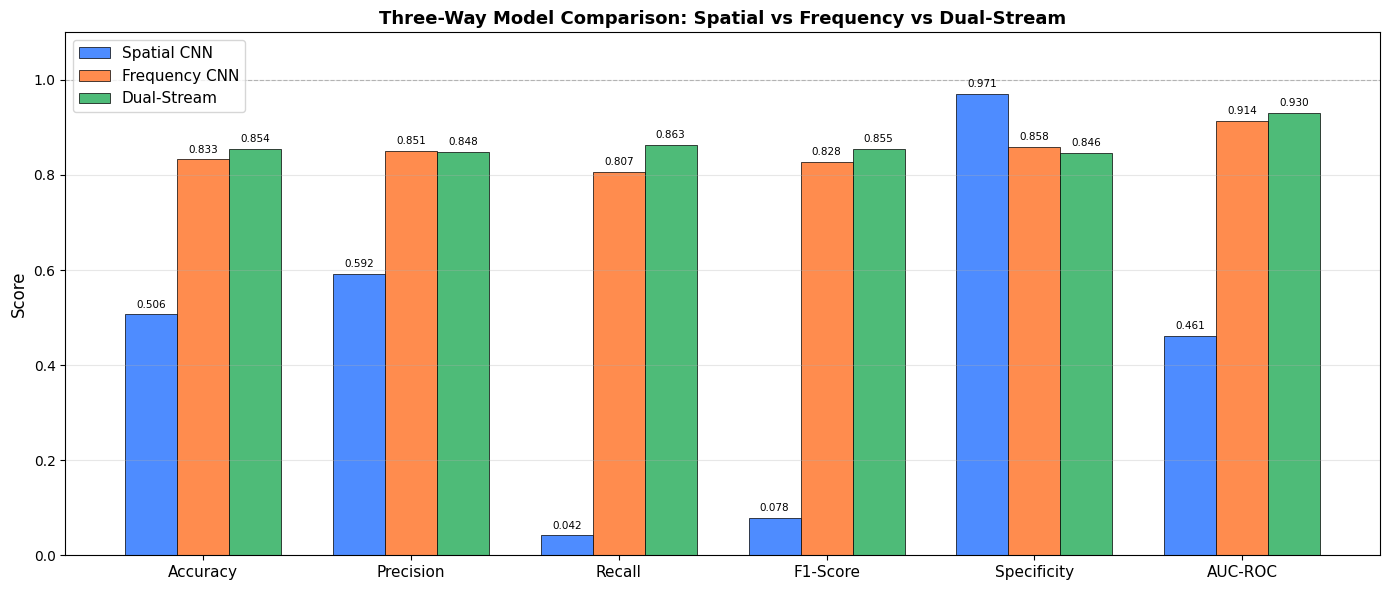

Chart saved to results/dual_stream/three_way_comparison.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# PASTE YOUR DUAL-STREAM EVALUATION RESULTS HERE
# Run phase_08_09 evaluation notebook on dual_stream_final.keras
# then paste the numbers below
# ============================================================


DUAL_METRICS = {
    "Accuracy"    : 0.8541,   
    "Precision"   : 0.8483,  
    "Recall"      : 0.8625,   
    "F1-Score"    : 0.8554,  
    "Specificity" : 0.8458,  
    "AUC-ROC"     : 0.9305,   
}

metrics     = list(SPATIAL_METRICS.keys())
spatial_vals = [SPATIAL_METRICS[m] for m in metrics]
freq_vals    = [FREQ_METRICS[m]    for m in metrics]
dual_vals    = [DUAL_METRICS[m]    for m in metrics]

# --- Print table ---
print("=" * 78)
print("FINAL THREE-WAY COMPARISON")
print("=" * 78)
print(f"{'Metric':<14} {'Spatial CNN':>14} {'Frequency CNN':>16} {'Dual-Stream':>14} {'Best':>10}")
print("-" * 78)
for m, s, f, d in zip(metrics, spatial_vals, freq_vals, dual_vals):
    best_val = max(s, f, d)
    best     = "Dual" if d == best_val else ("Freq" if f == best_val else "Spatial")
    print(f"{m:<14} {s:>14.4f} {f:>16.4f} {d:>14.4f} {best:>10}")
print("=" * 78)

# --- Bar chart ---
x      = np.arange(len(metrics))
width  = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width, spatial_vals, width, label="Spatial CNN",    color="#4e8cff", edgecolor="black", linewidth=0.5)
b2 = ax.bar(x,          freq_vals,    width, label="Frequency CNN",  color="#ff8c4e", edgecolor="black", linewidth=0.5)
b3 = ax.bar(x + width,  dual_vals,    width, label="Dual-Stream",    color="#4ebb78", edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Three-Way Model Comparison: Spatial vs Frequency vs Dual-Stream",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax.grid(axis="y", alpha=0.3)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=7.5)

plt.tight_layout()

import os
os.makedirs(RESULT_DIR, exist_ok=True)
plt.savefig(os.path.join(RESULT_DIR, "three_way_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to results/dual_stream/three_way_comparison.png")

---
## Phase 10 Complete

| Component | Detail |
|---|---|
| Stream 1 | EfficientNetB0 on RGB (spatial) |
| Stream 2 | EfficientNetB0 on DCT (frequency) |
| Fusion | Concatenation → Dense(256) → Dropout(0.5) → Sigmoid |
| Frozen training | 10 epochs @ lr=1e-3 |
| Fine-tune training | 10 epochs @ lr=1e-5 (top 20 layers each) |
| Parameters | ~2× single-stream (two backbones) |

**Next → Phase 11: Grad-CAM Explainability**

## Download Phase 10 Outputs

Run this cell after training is complete. The `.keras` model file is required by Phase 11 and Phase 12.

In [14]:
import shutil, os

OUTPUT_FILES = [
    "/kaggle/working/models/dual_stream_final.keras",
    "/kaggle/working/results/dual_stream/dual_stream_training_history.png",
    "/kaggle/working/checkpoints/dual_stream_best.keras",
    # Evaluation outputs
    "/kaggle/working/results/dual_stream/dual_stream_eval_metrics.txt",
    "/kaggle/working/results/dual_stream/dual_stream_metrics_bar.png",
    "/kaggle/working/results/dual_stream/dual_stream_confusion_matrix.png",
    "/kaggle/working/results/dual_stream/dual_stream_roc_curve.png",
]

os.makedirs("/kaggle/working/phase_10_bundle", exist_ok=True)
for f in OUTPUT_FILES:
    if os.path.exists(f):
        shutil.copy(f, "/kaggle/working/phase_10_bundle/")

shutil.make_archive("/kaggle/working/phase_10_outputs", "zip", "/kaggle/working/phase_10_bundle")

print("Files packaged:")
for f in OUTPUT_FILES:
    exists = os.path.exists(f)
    size   = round(os.path.getsize(f) / (1024 * 1024), 2) if exists else 0
    print(f"  {'OK' if exists else 'MISSING':<8} {os.path.basename(f):<45} {size} MB")

print()
print("Download: /kaggle/working/phase_10_outputs.zip")
print()
print("IMPORTANT: dual_stream_final.keras is required by Phase 11 and Phase 12.")

Files packaged:
  OK       dual_stream_final.keras                       60.64 MB
  OK       dual_stream_training_history.png              0.12 MB
  OK       dual_stream_best.keras                        60.64 MB
  OK       dual_stream_eval_metrics.txt                  0.0 MB
  OK       dual_stream_metrics_bar.png                   0.04 MB
  OK       dual_stream_confusion_matrix.png              0.02 MB
  OK       dual_stream_roc_curve.png                     0.05 MB

Download: /kaggle/working/phase_10_outputs.zip

IMPORTANT: dual_stream_final.keras is required by Phase 11 and Phase 12.
